<a href="https://www.kaggle.com/code/vladosht/simple-stock-picking-model?scriptVersionId=293152216" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

DISCLAIMER: The results of this model **must not** in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.

The intuition behind this stock-picking model was to test if a portfolio could be constructed which grows linearly over time with as little variance as possible. The slope of the requested linear growth is a hyperparameter.

In [1]:
import torch, time, itertools
import numpy as np
import pandas as pd
from sklearn import base, utils
from matplotlib import pyplot as plt

In [2]:
# Instead of using the entire ticker universe of the base dataset, I only use a small subset of tickers I have collected for test purposes.
# They are supposed to represent companies with as varied properties as possible.
test_tickers = pd.read_csv('https://storage.googleapis.com/vladosht/my_test_tickers.csv.gz')['ticker'].to_list()
len(test_tickers)

385

In [3]:
# Load the base dataset with monthly prices and restrict it to the test tickers.
dataset = pd.read_csv('/kaggle/input/monthly-us-stock-prices/prices.csv').pivot_table(
    index='date',values='price',columns='ticker').dropna(axis='columns')
dataset = dataset[dataset.columns[dataset.columns.isin(test_tickers)]]
dataset = dataset.drop(columns=dataset.columns[dataset.max()>5000])
dataset = dataset.drop(columns=dataset.columns[dataset.min()<1])
dataset.index = pd.to_datetime(dataset.index).date
dataset.shape

(192, 248)

In [4]:
# I do support GPU processing, but it does not seem to add speed compared to the CPU for this particular model.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Torch threads:',torch.get_num_threads())
print(torch.ones(1).to(device))

Torch threads: 2
tensor([1.])


The following is a custom scikit-learn estimator that wraps the core pytorch model.

In [5]:
class PortfolioOptimizer(torch.nn.Module):
    def __init__(self, data):
        super().__init__()
        self.register_buffer('data_x',torch.arange(data.shape[0],dtype=data.dtype).reshape(-1,1))
        self.coefs = torch.nn.Parameter(torch.rand(data.shape[1]))
        self.data_x_mean = self.data_x.mean()
        
    def get_loss(self, data, slope):
        # Use Softmax to force weights to sum to 1
        # This prevents the optimizer from "cheating" by setting everything to 0
        # This was Gemini's idea :-)
        self.weights = torch.softmax(self.coefs.abs(), dim=0)

        # Calculate the target based on current coefficients
        data_y = (data * self.weights).sum(dim=1, keepdim=True)  # Shape: (N, 1)

        # We set the slope of the linear growth as a hyperparameter, but we have to compute the intercept of the line.
        # Gemini AI helped me with this formula
        intercept = data_y.mean() - (slope * self.data_x_mean)

        # Now compute the line...
        y_pred = slope * self.data_x + intercept # Shape: (N, 1)

        # ...and the variance around the line
        loss = (data_y - y_pred)**2 # Shape: (N, 1)

        # We will minimze the total variance.
        return loss.sum()


class PortfolioEstimator(base.RegressorMixin, base.BaseEstimator):
    def __init__(self, slope = 0.1, patience=10, tolerance=0.999, learn_rate=0.8, verbose=False):
        self.slope = slope
        self.patience = patience
        self.tolerance = tolerance
        self.learn_rate = learn_rate
        self.verbose = verbose

        # Internal state for early stopping
        self._best_loss = np.inf
        self._patience_counter = 0

    def _should_stop(self, current_loss):
        """
        Returns True if training should stop.
        Resets counter only if current_loss is strictly less than best_loss
        for patience number of epochs.
        """
        if current_loss < self.tolerance * self._best_loss:
            self._best_loss = current_loss
            self._patience_counter = 0
            return False
        else:
            self._patience_counter += 1
            return self._patience_counter >= self.patience
            
    def fit(self, X, y = None):
        """
        Compute the weights for a linear combination of the input features (ticker prices),
        where the resulting line grows with the slope given at initialization.
        """
        self.feature_names_in_ = list(X.columns)
        self.n_features_in_ = len(self.feature_names_in_)

        data = torch.nn.Buffer(torch.tensor(X.to_numpy())).to(device)
        self.portfolio_optimizer_ = PortfolioOptimizer(data).to(device)
        
        optimizer = torch.optim.Adagrad(params = self.portfolio_optimizer_.parameters(), lr = self.learn_rate)

        start_time = time.time()
        last_print_time = start_time
        for epoch in itertools.count():
            optimizer.zero_grad()
            loss = self.portfolio_optimizer_.get_loss(data, self.slope)
            early_stop = self._should_stop(loss)
            loss.backward()
            optimizer.step()
            # Print if one second has passed or if it is the start/end
            current_time = time.time()
            if (current_time - last_print_time) >= 1 or epoch == 0 or early_stop:
                if self.verbose:
                    print(f"Epoch={epoch:5d} | Time={current_time-start_time:.1f}s | Loss={loss.item():.6f}")
                last_print_time = current_time
            if early_stop:
                break

        self.weights_ = pd.Series(index=self.feature_names_in_,
                                  data=self.portfolio_optimizer_.weights.detach().numpy())
        return self

    def predict(self, X):
        utils.validation.check_is_fitted(self)
        return (X * self.weights_)

# Here I do a test fit, because this way it is easier to debug the estimator code in this cell.
PortfolioEstimator(verbose=True).fit(dataset.head(10))

Epoch=    0 | Time=0.0s | Loss=30.278248
Epoch= 1267 | Time=1.0s | Loss=0.023888
Epoch= 1290 | Time=1.1s | Loss=0.023833


PortfolioEstimator(verbose=True)

Although obviously possible, finding a portfolio that grows linearly over the entire timespan and ticker universe is somewhat pointless, because over large periods of time the business environment of companies and their internal operations can change significantly.

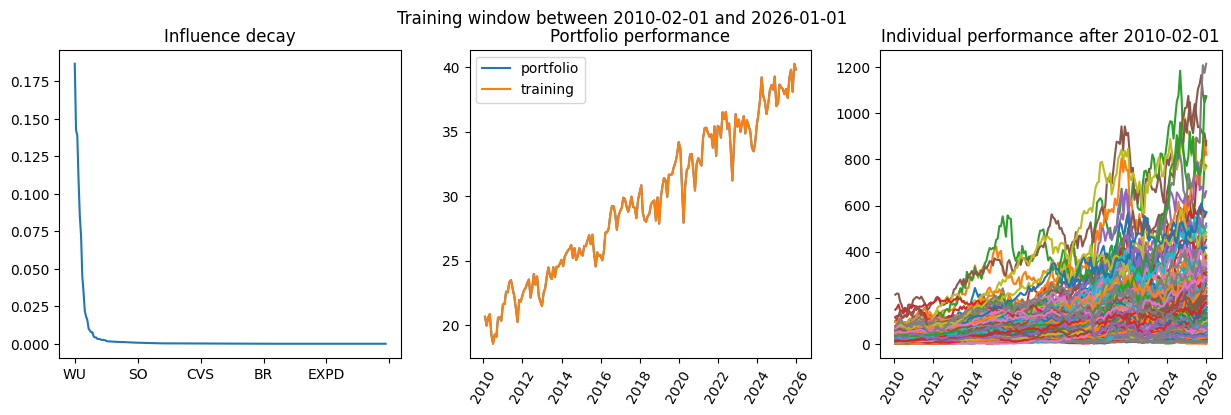

In [6]:
def plot_one_window(X, top_n=3):
    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))
    fig.suptitle(f"Training window between {X.index[0]} and {X.index[-1]}")
    estimator = PortfolioEstimator(verbose=False).fit(X)
    weights = estimator.weights_.sort_values(ascending=False).rename(X.index[-1])
    weights.plot(ax=ax[0], title='Influence decay')
    best_picks = weights.head(top_n).index.to_list()
    portfolio_prediction = estimator.predict(dataset)[best_picks].sum(axis='columns').rename('portfolio').to_frame()
    portfolio_prediction['training'] = estimator.predict(X)[best_picks].sum(axis='columns')
    portfolio_prediction.plot(ax=ax[1], rot=60, title='Portfolio performance',legend=True)
    dataset[dataset.index>=X.index.min()][best_picks].plot(ax=ax[2], rot=60,
                                                           title = f"Individual performance after {X.index[0]}",
                                                           legend = True if top_n<=10 else False)
    plt.show(fig)
    return weights, best_picks
dummy = plot_one_window(dataset, top_n=len(dataset.columns))

A better approach is to train for a fixed window size of months and then see how a portfolio of the top N most influential tickers develops both before the training period and most importantly, after it.

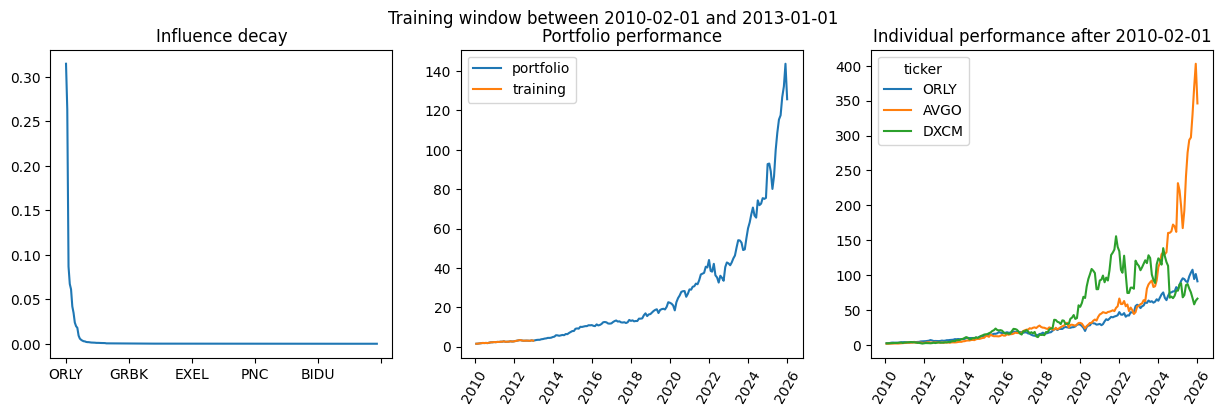

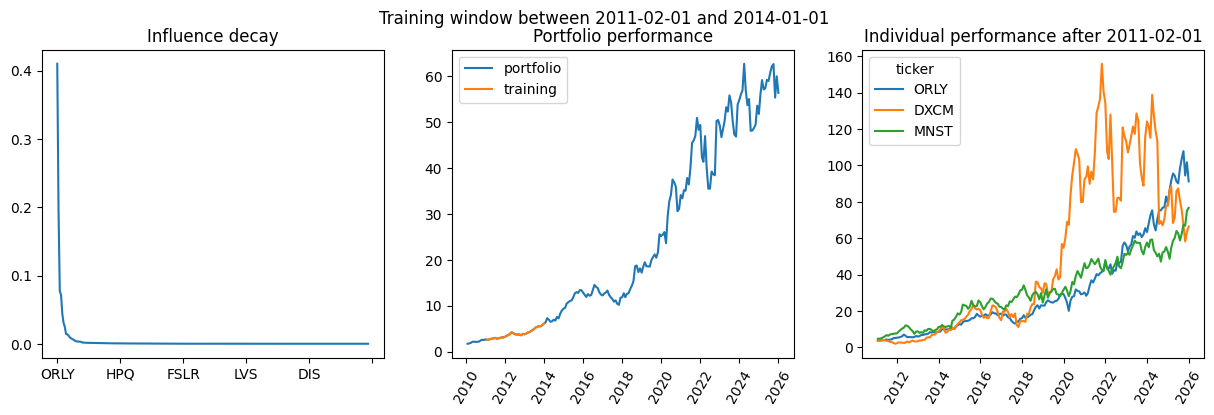

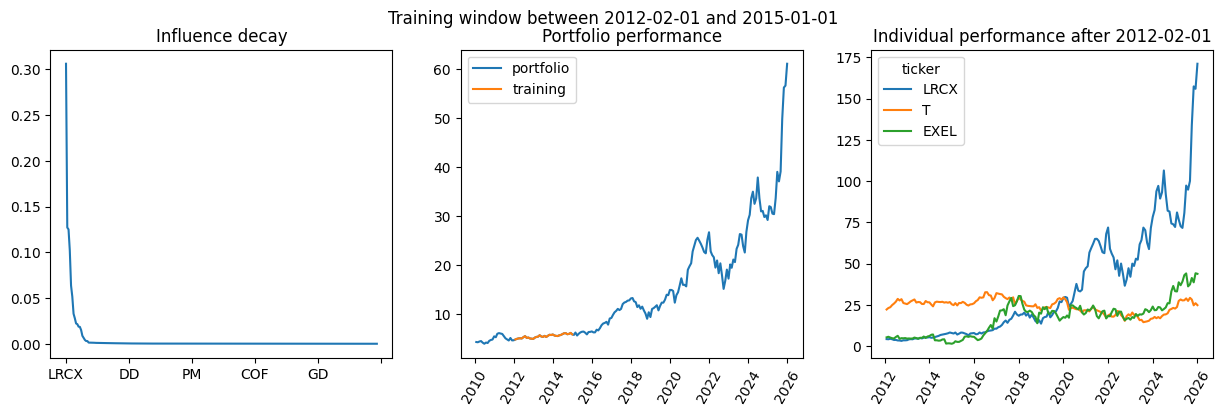

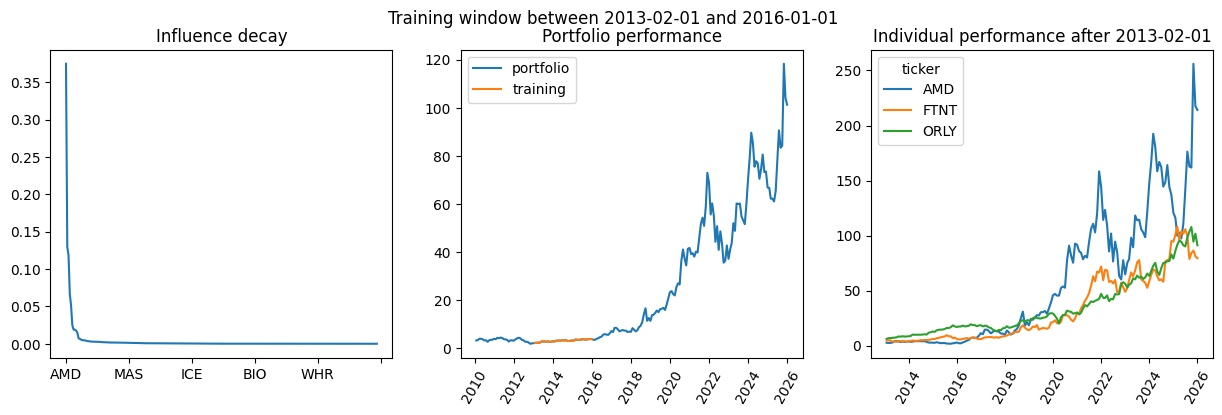

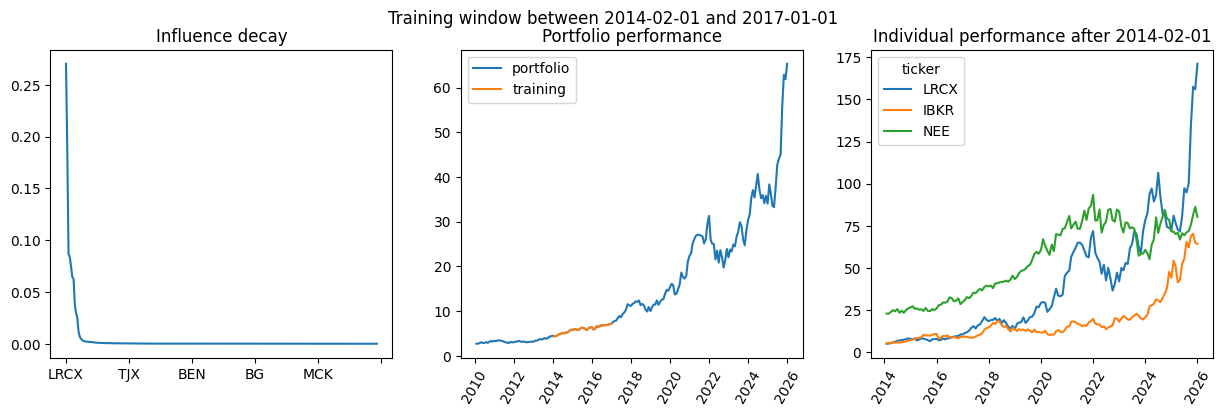

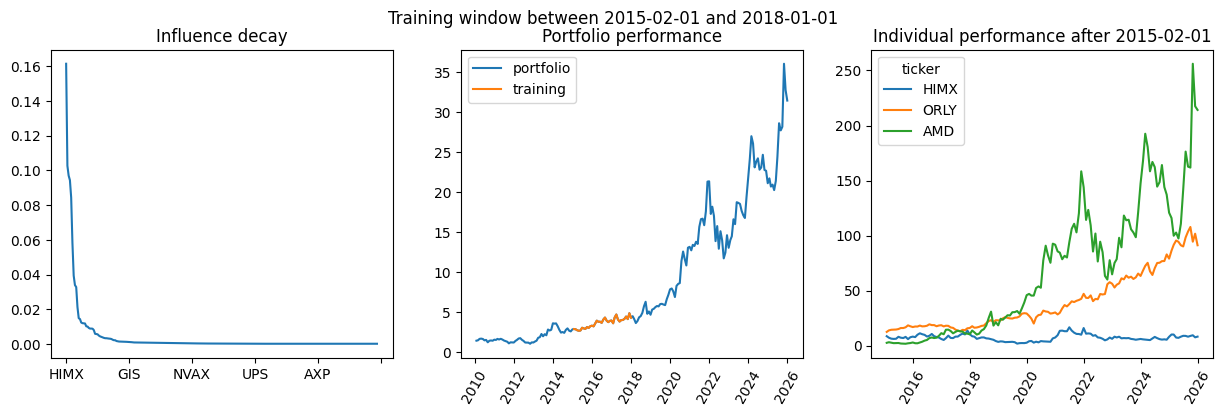

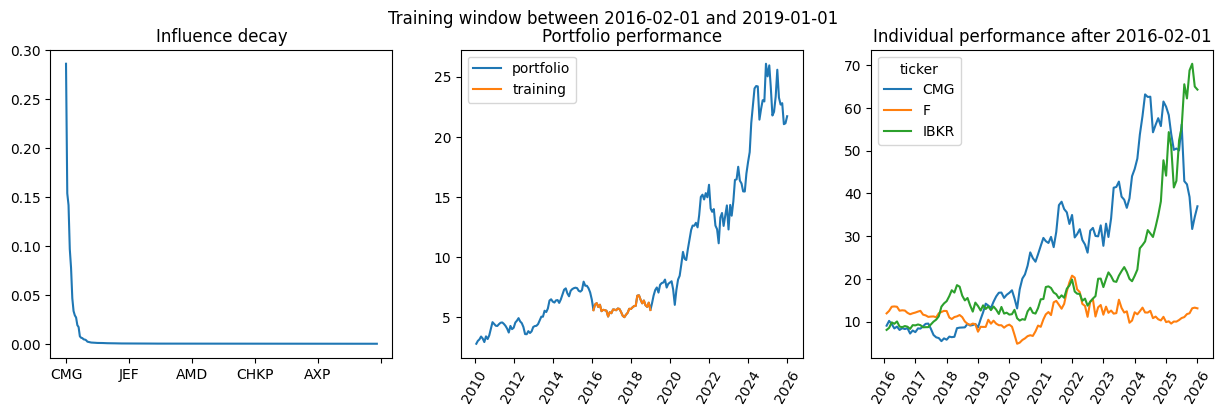

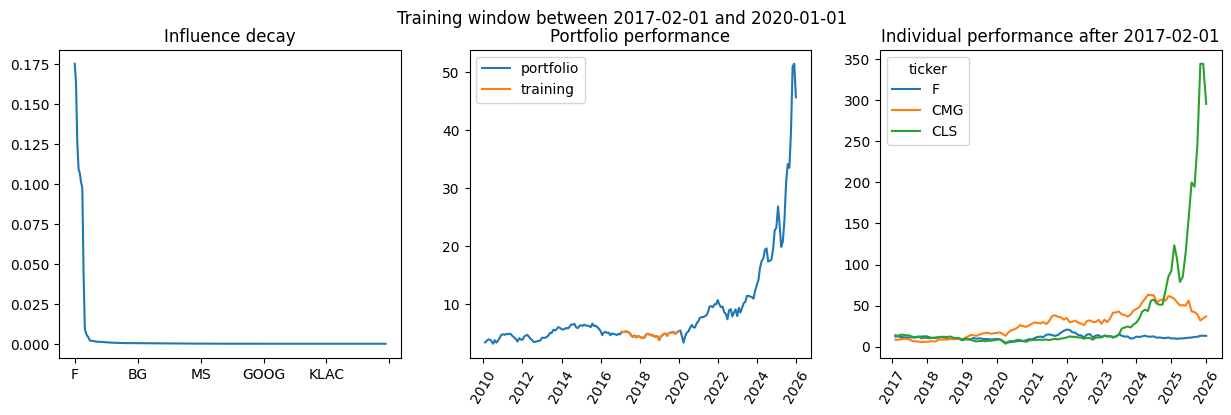

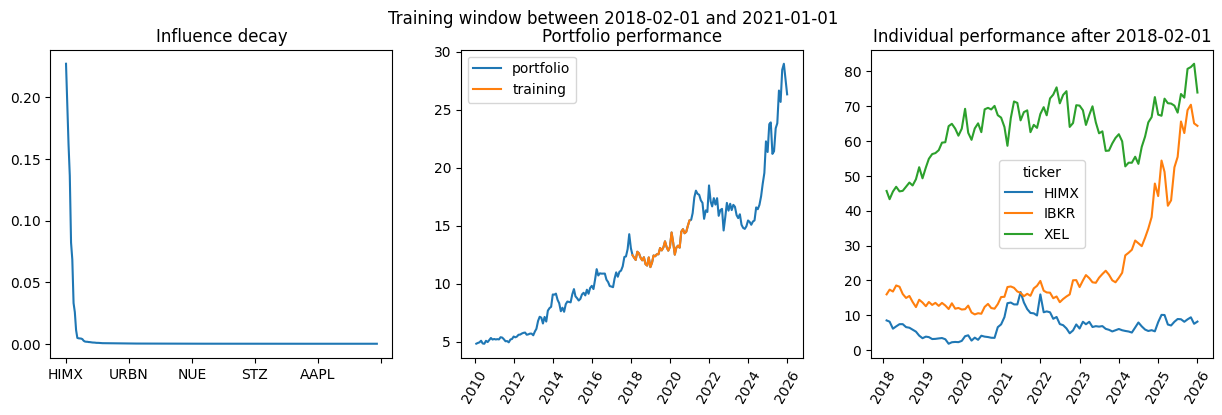

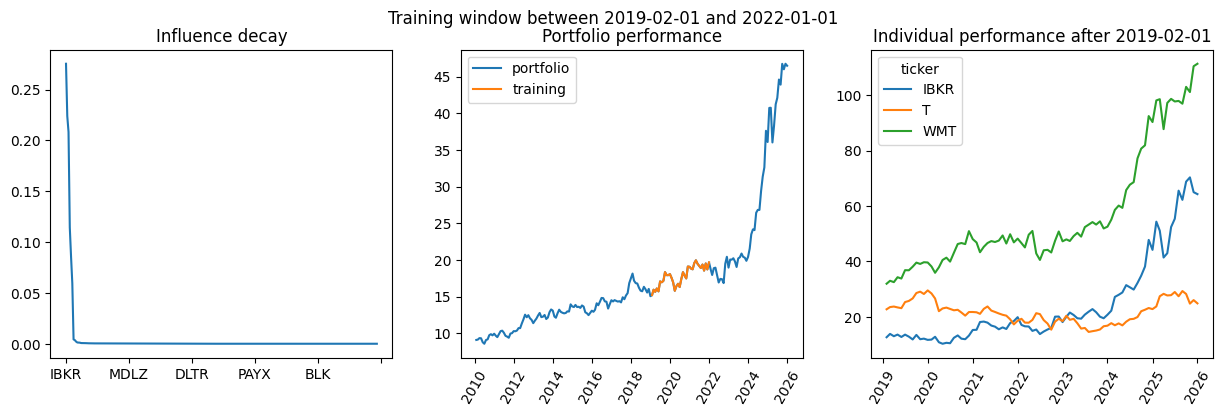

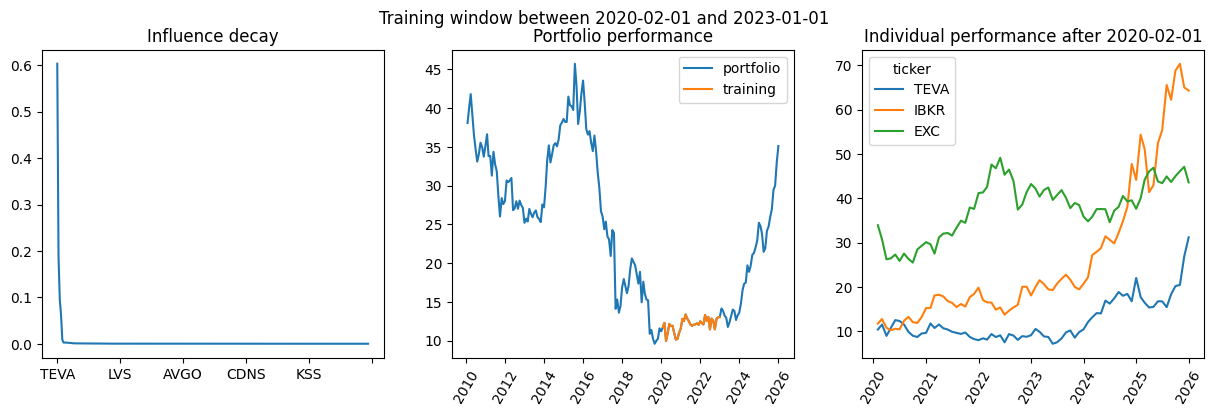

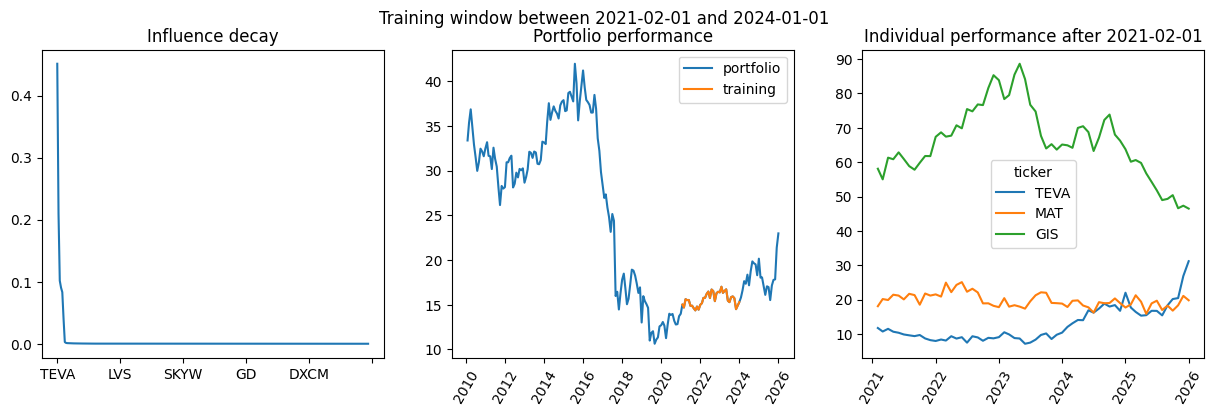

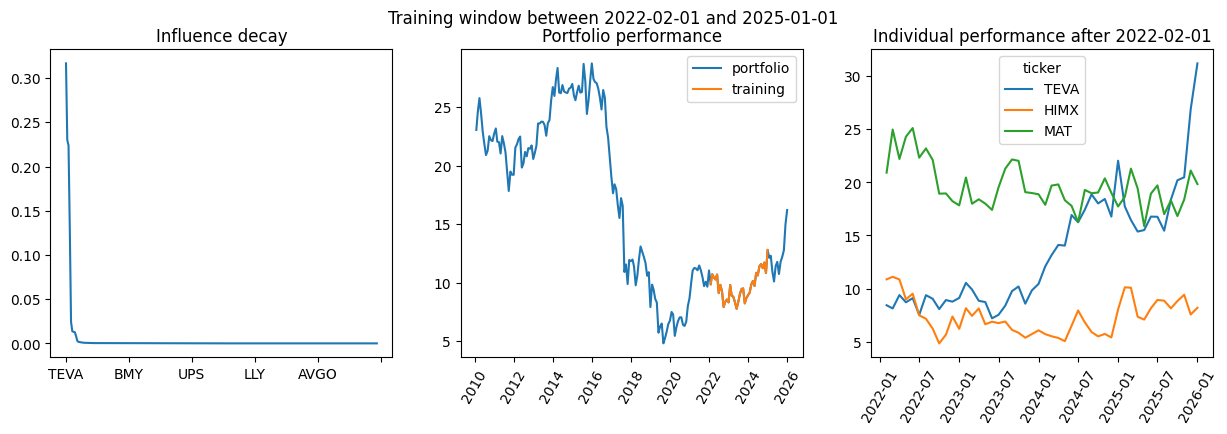

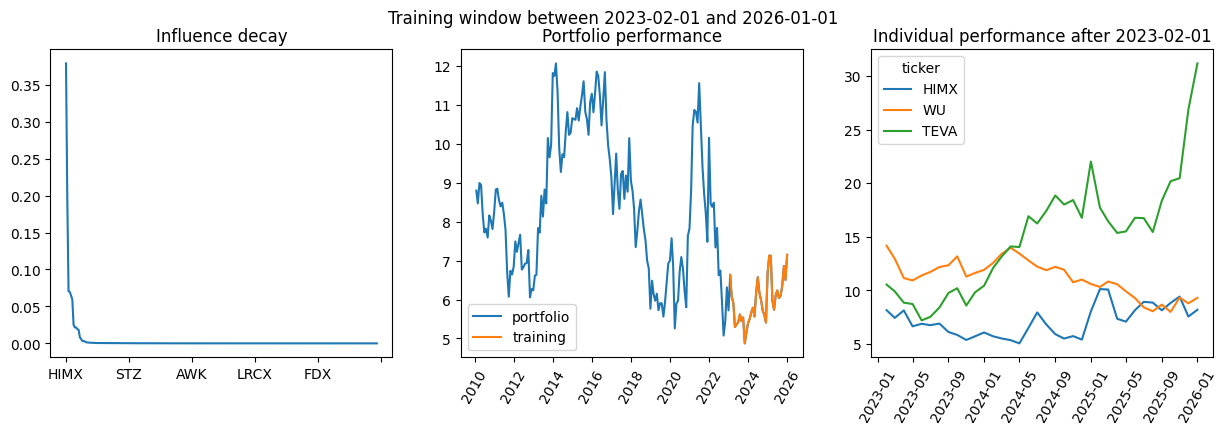

,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
AMD,0.000185,0.000541,0.004207,0.374645,0.002495,0.096953,0.000108,0.000041,0.000031,0.000022,0.000031,0.000013,0.000019,0.000078
AVGO,0.263546,0.014187,0.002993,0.001754,0.000314,0.001366,0.096682,0.000762,0.000302,0.000021,0.000050,0.000014,0.000019,0.000028
CLS,0.000394,0.001415,0.008756,0.018923,0.001474,0.014862,0.006150,0.126365,0.001173,0.003575,0.008794,0.083191,0.000019,0.000029
CMG,0.001037,0.000774,0.000697,0.002894,0.062777,0.094357,0.286077,0.163212,0.003778,0.000159,0.000173,0.090436,0.000297,0.003052
DXCM,0.086798,0.196476,0.000712,0.007284,0.000687,0.010177,0.000251,0.000044,0.000049,0.000017,0.000017,0.000013,0.000102,0.000153
EXC,0.000885,0.003703,0.000481,0.002844,0.000376,0.001709,0.000597,0.101167,0.068406,0.002146,0.095289,0.000669,0.000324,0.021589
EXEL,0.000074,0.001030,0.124984,0.051662,0.083635,0.000207,0.000139,0.000385,0.033050,0.059510,0.002109,0.002689,0.013765,0.069730
F,0.000156,0.000350,0.032807,0.002913,0.000488,0.005701,0.153605,0.175337,0.004766,0.000600,0.002543,0.000437,0.000649,0.001510
FTNT,0.000486,0.001350,0.006370,0.129683,0.037705,0.012345,0.001159,0.000403,0.004452,0.000017,0.000030,0.000018,0.000046,0.000046
GIS,0.005808,0.000151,0.000122,0.000359,0.000075,0.001123,0.000173,0.000150,0.000159,0.000386,0.062235,0.101641,0.001467,0.000241


In [7]:
window_size = 12 * 3
windows = [dataset.iloc[window:window+window_size] for window in range(0, 1+len(dataset)-window_size, 12)]
window_results = list(map(plot_one_window, windows))

weights_per_window = pd.concat([window[0] for window in window_results], axis='columns')
best_picks_per_window = sorted(list(set([a_pick for window in window_results for a_pick in window[1]])))
weights_per_window = weights_per_window.loc[best_picks_per_window]
weights_per_window.columns = pd.to_datetime(weights_per_window.columns).year
weights_per_window

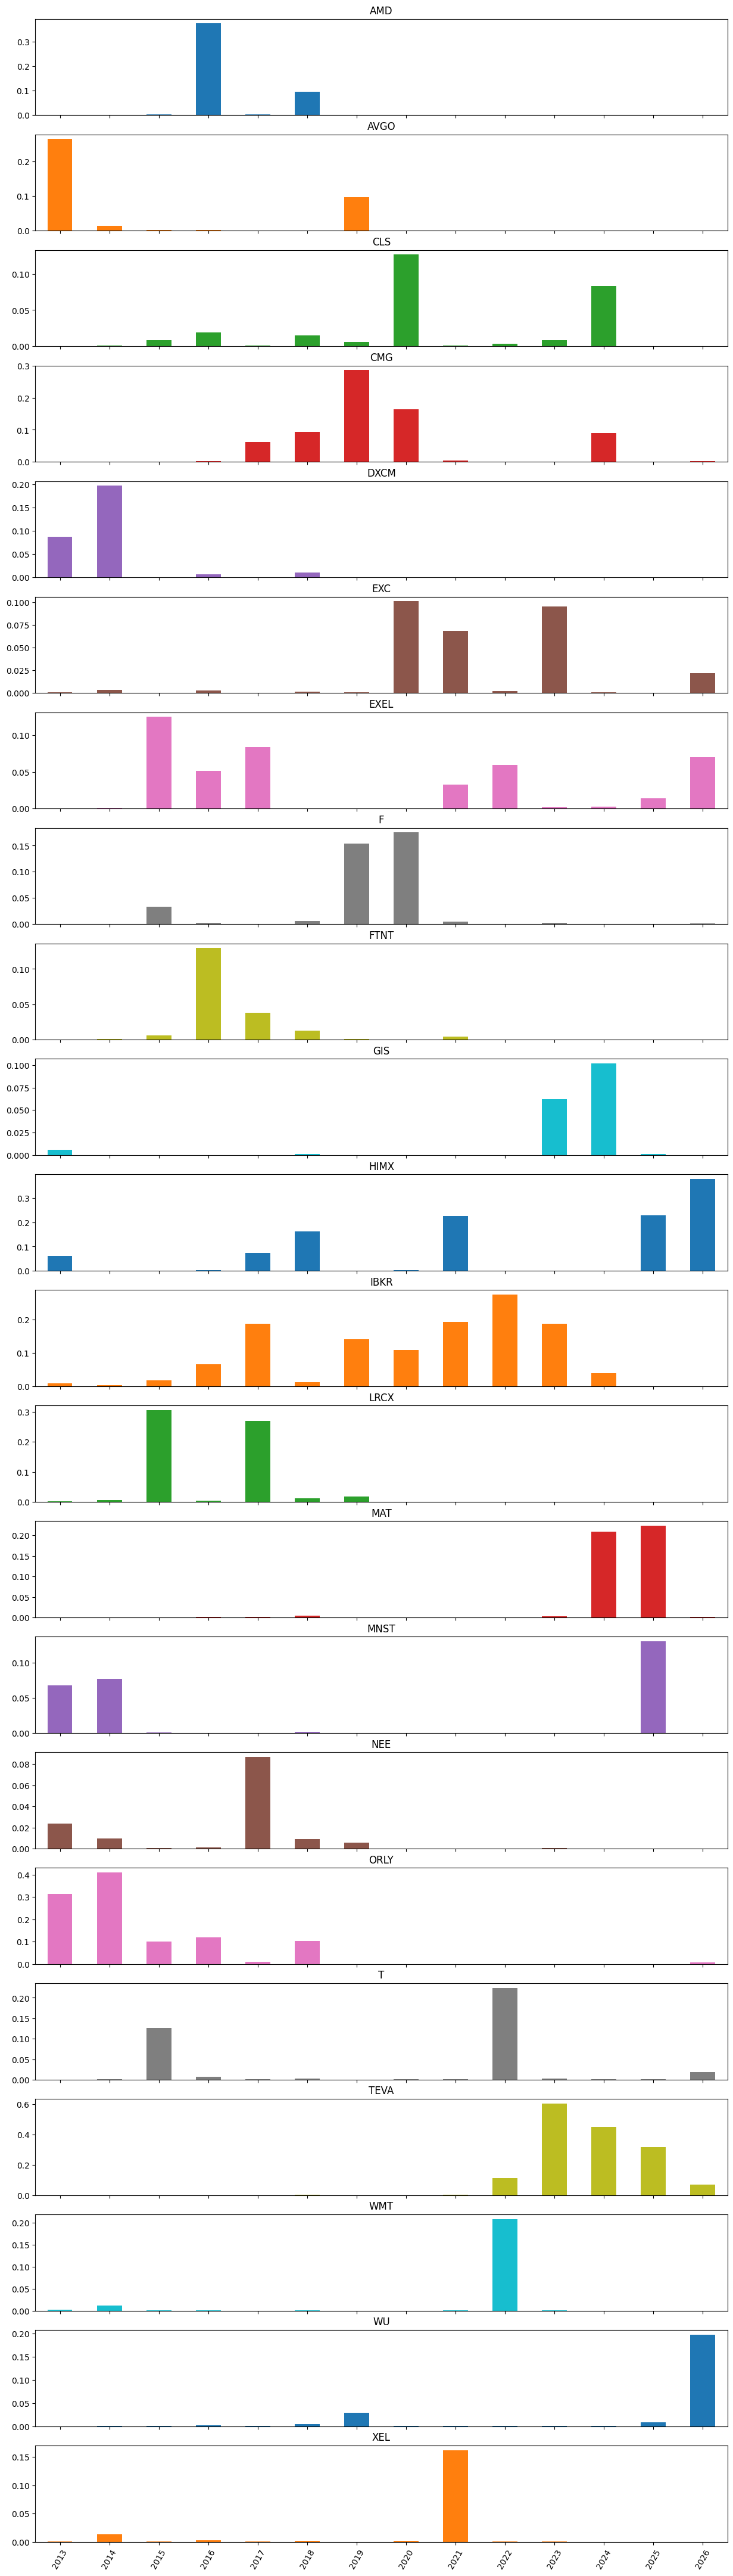

In [8]:
# Plot the collected weights for all training windows.
weights_per_window.T.plot.bar(figsize=(15,2.5*len(weights_per_window)), rot=60, subplots=True, legend=False)
plt.show()

DISCLAIMER: The results of this model **must not** in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.